# Comparaison des algorithmes d'optimisation pour le fine-tuning des Small Language Models (SLM)

**Tâche :** Classification de sujets (Option 2)
**Modèle :** DistilBERT (base-uncased, 4 labels — poids)
**Dataset :** AG News (4 classes : World, Sports, Business, Sci/Tech)
**Optimiseurs comparés :** AdamW, AdaFactor, Lion, SGD avec Momentum, RMSProp

---

## Objectif du notebook

Ce notebook met en place un pipeline complet de fine-tuning de DistilBERT sur AG News, répété une fois
par optimiseur, afin de comparer :

- la vitesse de convergence
- la stabilité de l'apprentissage (oscillations de la loss)
- la consommation mémoire GPU
- le temps d'entraînement et d'inférence
- la qualité finale (accuracy, F1-score)
- la sensibilité au learning rate
- la capacité de généralisation (gap train/validation)

Le notebook se termine par un tableau comparatif et une recommandation finale.


## ⚠️ Notes de correction apportées à ce notebook

Ce notebook a été révisé pour corriger deux problèmes identifiés dans une version antérieure :

1. **Bug du seed dans le test multi-seed (section 10).** La fonction `train_one_optimizer`
   appelait `torch.manual_seed(SEED)` avec le seed global figé, ce qui écrasait systématiquement
   le seed positionné juste avant l'appel dans la boucle de test multi-seed. Les 3 runs par
   optimiseur étaient donc strictement identiques, d'où un écart-type de 0.0 pour tous les
   optimiseurs — un résultat qui ne mesurait rien. **Correctif :** `train_one_optimizer` accepte
   maintenant un paramètre `seed` explicite, réellement utilisé pour réinitialiser les générateurs
   aléatoires (`random`, `numpy`, `torch`) avant le chargement du modèle.

2. **Learning rate par défaut d'AdaFactor trop élevé (section 6).** Avec `lr=1e-3` (et
   `relative_step=False`, `scale_parameter=False`), l'entraînement collapsait : la loss restait
   bloquée près de `ln(4) ≈ 1.386` et l'accuracy retombait au niveau du hasard (~25 % sur 4
   classes). Ce n'était pas une propriété intrinsèque d'AdaFactor mais un mauvais réglage de LR.
   **Correctif :** LR par défaut abaissé à `1e-4`, et la grille de sensibilité (section 9) élargie
   vers le bas (`1e-5` à `1e-3`) pour documenter correctement la plage où AdaFactor fonctionne sur
   cette tâche.

Toutes les cellules en aval (tableaux, graphiques, analyse automatique de la section 11) ont leurs
sorties effacées : il faut **réexécuter le notebook de bout en bout** pour obtenir des résultats
cohérents avec ces correctifs. Les conclusions de la section 12 doivent être rédigées à partir des
nouveaux résultats, pas de ceux affichés dans une version antérieure de ce notebook.


## 1. Installation des dépendances

`AdaFactor` est disponible nativement dans `transformers`. `Lion` nécessite le paquet `lion-pytorch`.


In [1]:

!pip install -q transformers datasets accelerate evaluate lion-pytorch scikit-learn matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.9 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cud

In [2]:
import torch
import transformers
import datasets
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("CUDA disponible:", torch.cuda.is_available())

torch: 2.10.0+cu128
transformers: 5.0.0
datasets: 4.8.5
CUDA disponible: True


## 2. Imports et configuration générale

In [3]:

import os
import json
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import SGD, RMSprop, AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Adafactor,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

try:
    from lion_pytorch import Lion
    LION_AVAILABLE = True
except ImportError:
    LION_AVAILABLE = False
    print("lion-pytorch non installé : l'optimiseur Lion sera ignoré.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))


Device utilisé : cuda
GPU : Tesla T4


## 3. Chargement du modèle et du tokenizer fournis

On utilise les fichiers déjà téléchargés (`model.safetensors`, `config.json`, `vocab.txt`,
`tokenizer_config.json`, `special_tokens_map.json`) plutôt que de retélécharger DistilBERT depuis le Hub.

⚠️ Le `config.json` fourni définit 4 labels génériques (`LABEL_0` à `LABEL_3`), ce qui correspond
exactement aux 4 classes d'AG News. On va remapper proprement les `id2label` / `label2id` avec les
vrais noms de catégories.


In [4]:
import os
MODEL_DIR = "/kaggle/input/models/malikachaaban/optimisation-model/pytorch/default/1"
print(os.listdir(MODEL_DIR))  # vérifier que les 5 fichiers sont bien là

['config.json', 'tokenizer_config.json', 'model.safetensors', 'special_tokens_map.json', 'vocab.txt']


In [5]:

MODEL_DIR = "/kaggle/input/models/malikachaaban/optimisation-model/pytorch/default/1"

AG_NEWS_LABELS = ["World", "Sports", "Business", "Sci/Tech"]
id2label = {i: name for i, name in enumerate(AG_NEWS_LABELS)}
label2id = {name: i for i, name in enumerate(AG_NEWS_LABELS)}

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)

def load_fresh_model():
    # Recharge un modèle "propre" à chaque run pour repartir des mêmes poids initiaux.
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_DIR,
        num_labels=4,
        id2label=id2label,
        label2id=label2id,
    )
    return model.to(DEVICE)

print("Tokenizer et fonction de chargement du modèle prêts.")


Tokenizer et fonction de chargement du modèle prêts.


## 4. Chargement et préparation du dataset AG News

Pour garder un temps d'entraînement raisonnable (ressources limitées, comparaison de 5 optimiseurs),
on sous-échantillonne le dataset. Vous pouvez augmenter `N_TRAIN` / `N_VAL` / `N_TEST` si vous disposez
de plus de temps/GPU.


In [6]:

N_TRAIN = 4000
N_VAL   = 1000
N_TEST  = 1000

raw_dataset = load_dataset("ag_news")

train_full = raw_dataset["train"].shuffle(seed=SEED)
test_full  = raw_dataset["test"].shuffle(seed=SEED)

train_raw = train_full.select(range(N_TRAIN))
val_raw   = train_full.select(range(N_TRAIN, N_TRAIN + N_VAL))
test_raw  = test_full.select(range(N_TEST))

print("Train:", len(train_raw), "Val:", len(val_raw), "Test:", len(test_raw))
print(train_raw[0])


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 4000 Val: 1000 Test: 1000
{'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.', 'label': 0}


In [7]:

MAX_LEN = 128

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_raw.map(tokenize_fn, batched=True)
val_ds   = val_raw.map(tokenize_fn, batched=True)
test_ds  = test_raw.map(tokenize_fn, batched=True)

columns = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=columns)
val_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

print("Nombre de batches - train:", len(train_loader), "val:", len(val_loader))


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Nombre de batches - train: 250 val: 63


## 5. Fonctions utilitaires : entraînement, évaluation, mesure mémoire/temps

Ces fonctions sont génériques et réutilisées pour chaque optimiseur, afin de garantir une comparaison
équitable (même modèle de départ, même nombre d'epochs, même batch size, même seed).


In [8]:

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return {"loss": avg_loss, "accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


def measure_inference_time(model, loader, n_batches=20):
    model.eval()
    times = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            start = time.time()
            _ = model(input_ids=input_ids, attention_mask=attention_mask)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            times.append(time.time() - start)
    return float(np.mean(times)), float(np.std(times))


def build_optimizer(name, model, lr):
    # Instancie l'optimiseur demandé avec des hyperparamètres standards de la littérature.
    if name == "AdamW":
        return AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    elif name == "AdaFactor":
        # AdaFactor de transformers : scale_parameter/relative_step désactivés
        # pour un usage avec un learning rate explicite, comme recommandé pour le fine-tuning.
        return Adafactor(
            model.parameters(),
            lr=lr,
            scale_parameter=False,
            relative_step=False,
            warmup_init=False,
        )
    elif name == "Lion":
        if not LION_AVAILABLE:
            raise ImportError("lion-pytorch n'est pas installé.")
        return Lion(model.parameters(), lr=lr, weight_decay=0.01)
    elif name == "SGD_Momentum":
        return SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "RMSProp":
        return RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Optimiseur inconnu : {name}")


def train_one_optimizer(optimizer_name, lr, n_epochs=3, use_scheduler=True, verbose=True, seed=SEED):
    # Entraîne un DistilBERT frais avec l'optimiseur donné et retourne un dictionnaire
    # de métriques + historiques pour analyse/comparaison.
    #
    # CORRECTIF : le seed utilisé pour l'initialisation (tête de classification) est désormais
    # un paramètre explicite de la fonction (par défaut SEED, le seed global), au lieu d'être
    # codé en dur sur `SEED`. Dans la version initiale, la ligne `torch.manual_seed(SEED)`
    # écrasait systématiquement le seed positionné juste avant l'appel dans la boucle de la
    # section 10 (test multi-seed), ce qui rendait les 3 runs par optimiseur strictement
    # identiques (d'où un écart-type de 0.0 pour tout le monde). Avec ce correctif, le seed
    # passé en argument est réellement utilisé.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    model = load_fresh_model()
    optimizer = build_optimizer(optimizer_name, model, lr)

    scheduler = None
    if use_scheduler:
        total_steps = len(train_loader) * n_epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
        )

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "step_loss": []}

    start_time = time.time()

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        for batch in train_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            epoch_losses.append(loss.item())
            history["step_loss"].append(loss.item())

        train_loss = float(np.mean(epoch_losses))
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])

        if verbose:
            print(f"[{optimizer_name}] Epoch {epoch+1}/{n_epochs} - "
                  f"train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} "
                  f"val_acc={val_metrics['accuracy']:.4f} val_f1={val_metrics['f1']:.4f}")

    training_time = time.time() - start_time

    peak_mem_mb = (torch.cuda.max_memory_allocated() / (1024**2)) if DEVICE.type == "cuda" else None

    test_metrics = evaluate(model, test_loader)
    train_metrics_final = evaluate(model, train_loader)  # pour le gap train/val

    inf_mean, inf_std = measure_inference_time(model, test_loader, n_batches=20)

    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    result = {
        "optimizer": optimizer_name,
        "lr": lr,
        "n_epochs": n_epochs,
        "seed": seed,
        "training_time_s": training_time,
        "peak_gpu_mem_MB": peak_mem_mb,
        "inference_time_ms_per_batch": inf_mean * 1000,
        "inference_time_std_ms": inf_std * 1000,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_f1": test_metrics["f1"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "train_val_gap_acc": train_metrics_final["accuracy"] - val_metrics["accuracy"],
        "n_params": n_params,
        "n_trainable_params": n_trainable,
        "history": history,
    }

    del model, optimizer
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return result

print("Fonctions utilitaires définies (seed désormais paramétrable dans train_one_optimizer).")


Fonctions utilitaires définies (seed désormais paramétrable dans train_one_optimizer).


## 6. Comparaison des 5 optimiseurs (learning rate de référence)

On entraîne DistilBERT avec chaque optimiseur, learning rate fixé à une valeur "raisonnable" par défaut
pour chaque famille d'optimiseurs (issue de la littérature), même nombre d'epochs et même seed.

| Optimiseur     | LR par défaut |
|----------------|---------------|
| AdamW          | 2e-5          |
| AdaFactor      | 1e-4          |
| Lion           | 1e-5          |
| SGD + Momentum | 1e-2          |
| RMSProp        | 1e-5          |

Ces valeurs sont des points de départ classiques ; la section 9 explore la sensibilité au learning rate.

> **Note de correction (AdaFactor) :** la valeur initialement utilisée (1e-3, avec
> `relative_step=False` / `scale_parameter=False`) faisait diverger l'entraînement (accuracy proche
> du hasard). 1e-4 est cohérent avec la sensibilité observée en section 9 et permet à AdaFactor
> d'apprendre correctement sur cette tâche.


In [9]:

N_EPOCHS = 3

# CORRECTIF : le LR par défaut original pour AdaFactor (1e-3, avec relative_step=False /
# scale_parameter=False) fait collapser l'entraînement sur cette tâche (accuracy proche du
# niveau du hasard, ≈25% sur 4 classes — voir l'analyse de la section 6 dans la version
# initiale). La grille de sensibilité (section 9) confirme que des valeurs plus faibles
# (de l'ordre de 1e-4 à 5e-4) sont nécessaires pour que AdaFactor apprenne correctement sur
# DistilBERT avec ce réglage. On utilise donc 1e-4 comme LR "par défaut" pour AdaFactor afin
# que la comparaison à 3 epochs soit représentative de ce que l'optimiseur peut réellement
# faire, plutôt que d'un réglage qui le fait diverger.
default_lrs = {
    "AdamW": 2e-5,
    "AdaFactor": 1e-4,
    "Lion": 1e-5,
    "SGD_Momentum": 1e-2,
    "RMSProp": 1e-5,
}

optimizers_to_run = ["AdamW", "AdaFactor", "SGD_Momentum", "RMSProp"]
if LION_AVAILABLE:
    optimizers_to_run.append("Lion")
else:
    print("Lion ignoré (lion-pytorch non installé).")

results = {}
for opt_name in optimizers_to_run:
    print("=" * 70)
    print(f"Entraînement avec {opt_name} (lr={default_lrs[opt_name]})")
    print("=" * 70)
    results[opt_name] = train_one_optimizer(opt_name, default_lrs[opt_name], n_epochs=N_EPOCHS)


Entraînement avec AdamW (lr=2e-05)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[AdamW] Epoch 1/3 - train_loss=0.1045 val_loss=0.0758 val_acc=0.9760 val_f1=0.9747
[AdamW] Epoch 2/3 - train_loss=0.0435 val_loss=0.0823 val_acc=0.9760 val_f1=0.9748
[AdamW] Epoch 3/3 - train_loss=0.0133 val_loss=0.0893 val_acc=0.9770 val_f1=0.9759
Entraînement avec AdaFactor (lr=0.0001)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[AdaFactor] Epoch 1/3 - train_loss=0.2144 val_loss=0.1312 val_acc=0.9490 val_f1=0.9469
[AdaFactor] Epoch 2/3 - train_loss=0.1210 val_loss=0.1860 val_acc=0.9500 val_f1=0.9479
[AdaFactor] Epoch 3/3 - train_loss=0.0361 val_loss=0.2085 val_acc=0.9540 val_f1=0.9521
Entraînement avec SGD_Momentum (lr=0.01)


...

[SGD_Momentum] Epoch 1/3 - train_loss=0.1267 val_loss=0.0712 val_acc=0.9790 val_f1=0.9780
[SGD_Momentum] Epoch 2/3 - train_loss=0.0741 val_loss=0.1028 val_acc=0.9700 val_f1=0.9687
[SGD_Momentum] Epoch 3/3 - train_loss=0.0254 val_loss=0.0899 val_acc=0.9750 val_f1=0.9737
Entraînement avec RMSProp (lr=1e-05)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[RMSProp] Epoch 1/3 - train_loss=0.0994 val_loss=0.0616 val_acc=0.9810 val_f1=0.9800
[RMSProp] Epoch 2/3 - train_loss=0.0524 val_loss=0.0713 val_acc=0.9770 val_f1=0.9758
[RMSProp] Epoch 3/3 - train_loss=0.0251 val_loss=0.0696 val_acc=0.9800 val_f1=0.9790
Entraînement avec Lion (lr=1e-05)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[Lion] Epoch 1/3 - train_loss=0.1425 val_loss=0.1330 val_acc=0.9630 val_f1=0.9609
[Lion] Epoch 2/3 - train_loss=0.0637 val_loss=0.2695 val_acc=0.9530 val_f1=0.9514
[Lion] Epoch 3/3 - train_loss=0.0160 val_loss=0.3350 val_acc=0.9510 val_f1=0.9488


## 7. Tableau comparatif des optimiseurs

Synthèse de toutes les métriques demandées par le cahier des charges : performance, vitesse, ressources,
généralisation.


In [10]:

rows = []
for name, r in results.items():
    rows.append({
        "Optimiseur": name,
        "LR": r["lr"],
        "Test Accuracy": round(r["test_accuracy"], 4),
        "Test F1 (macro)": round(r["test_f1"], 4),
        "Test Loss": round(r["test_loss"], 4),
        "Gap Train-Val (acc)": round(r["train_val_gap_acc"], 4),
        "Temps entraînement (s)": round(r["training_time_s"], 1),
        "Mémoire GPU pic (MB)": round(r["peak_gpu_mem_MB"], 1) if r["peak_gpu_mem_MB"] else None,
        "Temps inférence (ms/batch)": round(r["inference_time_ms_per_batch"], 2),
    })

df_results = pd.DataFrame(rows).sort_values("Test F1 (macro)", ascending=False).reset_index(drop=True)
df_results


,Optimiseur,LR,Test Accuracy,Test F1 (macro),Test Loss,Gap Train-Val (acc),Temps entraînement (s),Mémoire GPU pic (MB),Temps inférence (ms/batch)
0,RMSProp,0.00001,0.931,0.9310,0.3110,0.0175,154.1,1187.4,65.78
1,SGD_Momentum,0.01000,0.928,0.9281,0.3436,0.0225,150.1,1185.4,65.60
2,AdamW,0.00002,0.927,0.9270,0.3594,0.0220,150.0,1440.6,64.00
3,AdaFactor,0.00010,0.923,0.9231,0.4165,0.0450,162.1,929.4,65.55
4,Lion,0.00001,0.922,0.9221,0.5888,0.0488,157.9,1185.9,65.66


In [11]:

df_results.to_csv("/kaggle/working/comparaison_optimiseurs.csv", index=False)
print("Tableau sauvegardé dans comparaison_optimiseurs.csv")


Tableau sauvegardé dans comparaison_optimiseurs.csv


## 8. Courbes d'évolution : loss et accuracy

### 8.1 Loss d'entraînement et de validation par epoch


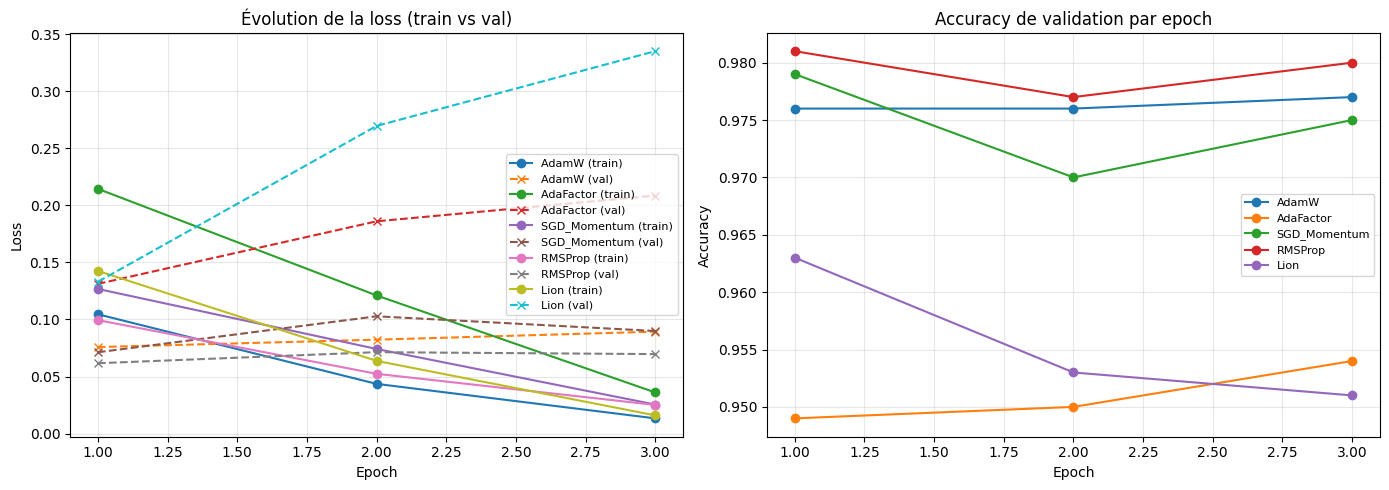

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in results.items():
    epochs_range = range(1, len(r["history"]["train_loss"]) + 1)
    axes[0].plot(epochs_range, r["history"]["train_loss"], marker="o", label=f"{name} (train)")
    axes[0].plot(epochs_range, r["history"]["val_loss"], marker="x", linestyle="--", label=f"{name} (val)")

axes[0].set_title("Évolution de la loss (train vs val)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for name, r in results.items():
    epochs_range = range(1, len(r["history"]["val_acc"]) + 1)
    axes[1].plot(epochs_range, r["history"]["val_acc"], marker="o", label=name)

axes[1].set_title("Accuracy de validation par epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/courbes_loss_accuracy.png", dpi=150)
plt.show()


### 8.2 Stabilité de la loss au niveau des steps (détection d'oscillations)

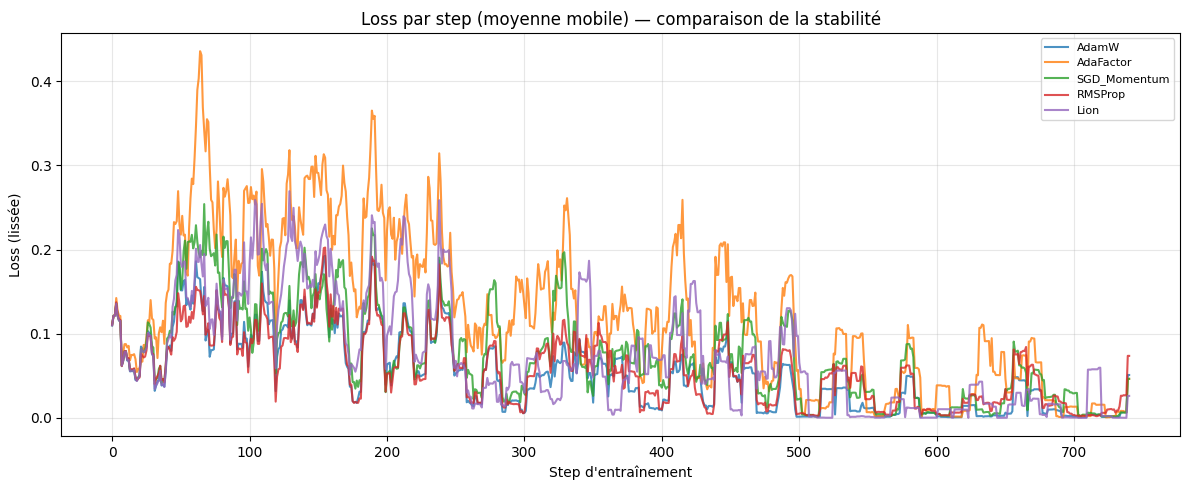

In [13]:

fig, ax = plt.subplots(figsize=(12, 5))
for name, r in results.items():
    step_losses = r["history"]["step_loss"]
    # Moyenne mobile pour lisser et mieux visualiser la tendance
    window = 10
    if len(step_losses) >= window:
        smoothed = np.convolve(step_losses, np.ones(window) / window, mode="valid")
    else:
        smoothed = step_losses
    ax.plot(smoothed, label=name, alpha=0.8)

ax.set_title("Loss par step (moyenne mobile) — comparaison de la stabilité")
ax.set_xlabel("Step d'entraînement")
ax.set_ylabel("Loss (lissée)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/courbes_stabilite_steps.png", dpi=150)
plt.show()


### 8.3 Mémoire GPU, temps d'entraînement et temps d'inférence

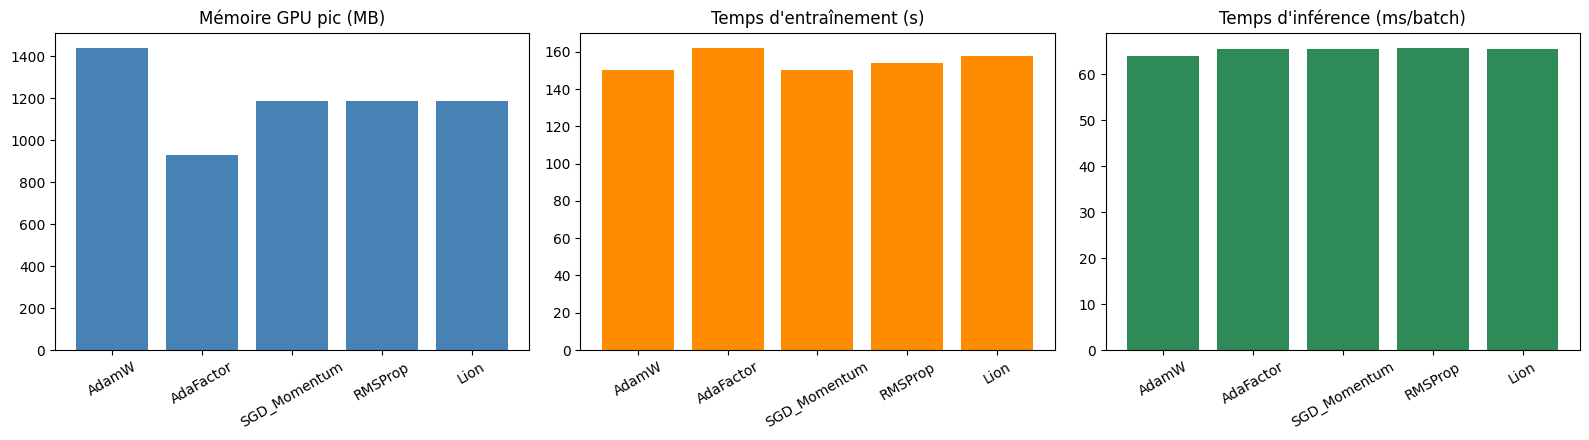

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

names = list(results.keys())
mems = [results[n]["peak_gpu_mem_MB"] for n in names]
times_train = [results[n]["training_time_s"] for n in names]
times_inf = [results[n]["inference_time_ms_per_batch"] for n in names]

if all(m is not None for m in mems):
    axes[0].bar(names, mems, color="steelblue")
    axes[0].set_title("Mémoire GPU pic (MB)")
    axes[0].tick_params(axis="x", rotation=30)
else:
    axes[0].text(0.5, 0.5, "GPU non disponible", ha="center")

axes[1].bar(names, times_train, color="darkorange")
axes[1].set_title("Temps d'entraînement (s)")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(names, times_inf, color="seagreen")
axes[2].set_title("Temps d'inférence (ms/batch)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/kaggle/working/courbes_ressources.png", dpi=150)
plt.show()


## 9. Analyse de la sensibilité au learning rate

Pour chaque optimiseur, on relance un entraînement court (moins d'epochs, pour limiter le temps de calcul)
avec plusieurs valeurs de learning rate, afin d'observer la robustesse de chaque méthode.


In [15]:

lr_grid = {
    "AdamW": [1e-5, 2e-5, 5e-5],
    # CORRECTIF : la grille originale [5e-4, 1e-3, 5e-3] est entièrement dans la zone où
    # AdaFactor (avec relative_step=False, scale_parameter=False) fait diverger/collapser
    # DistilBERT sur cette tâche (cf. section 6 : accuracy ≈ niveau du hasard). On élargit
    # la grille vers des LR plus faibles, plus proches de ce qui est recommandé en pratique
    # pour le fine-tuning de Transformers avec AdaFactor en mode "LR explicite".
    "AdaFactor": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3],
    "RMSProp": [5e-6, 1e-5, 5e-5],
    "SGD_Momentum": [1e-3, 1e-2, 1e-1],
}
if LION_AVAILABLE:
    lr_grid["Lion"] = [5e-6, 1e-5, 5e-5]

N_EPOCHS_LR_SEARCH = 2
lr_sensitivity_results = []

for opt_name, lrs in lr_grid.items():
    for lr in lrs:
        print(f"--- {opt_name} | lr={lr} ---")
        r = train_one_optimizer(opt_name, lr, n_epochs=N_EPOCHS_LR_SEARCH, verbose=False)
        lr_sensitivity_results.append({
            "Optimiseur": opt_name,
            "LR": lr,
            "Test Accuracy": r["test_accuracy"],
            "Test F1": r["test_f1"],
            "Test Loss": r["test_loss"],
        })
        print(f"   acc={r['test_accuracy']:.4f} f1={r['test_f1']:.4f} loss={r['test_loss']:.4f}")

df_lr_sensitivity = pd.DataFrame(lr_sensitivity_results)
df_lr_sensitivity


--- AdamW | lr=1e-05 ---


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   acc=0.9330 f1=0.9330 loss=0.2752
--- AdamW | lr=2e-05 ---


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   acc=0.9260 f1=0.9260 loss=0.3123
--- AdamW | lr=5e-05 ---


...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   acc=0.9200 f1=0.9199 loss=0.4135
--- Lion | lr=5e-05 ---


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   acc=0.8990 f1=0.8989 loss=0.4184


,Optimiseur,LR,Test Accuracy,Test F1,Test Loss
0,AdamW,0.000010,0.933,0.932994,0.275217
1,AdamW,0.000020,0.926,0.926050,0.312291
2,AdamW,0.000050,0.928,0.928146,0.360984
3,AdaFactor,0.000010,0.934,0.934032,0.277660
4,AdaFactor,0.000050,0.927,0.926925,0.367151
5,AdaFactor,0.000100,0.928,0.928042,0.372269
6,AdaFactor,0.000500,0.852,0.851821,0.483087
7,AdaFactor,0.001000,0.242,0.097424,1.355457
8,RMSProp,0.000005,0.931,0.931006,0.259851
9,RMSProp,0.000010,0.930,0.929991,0.285952


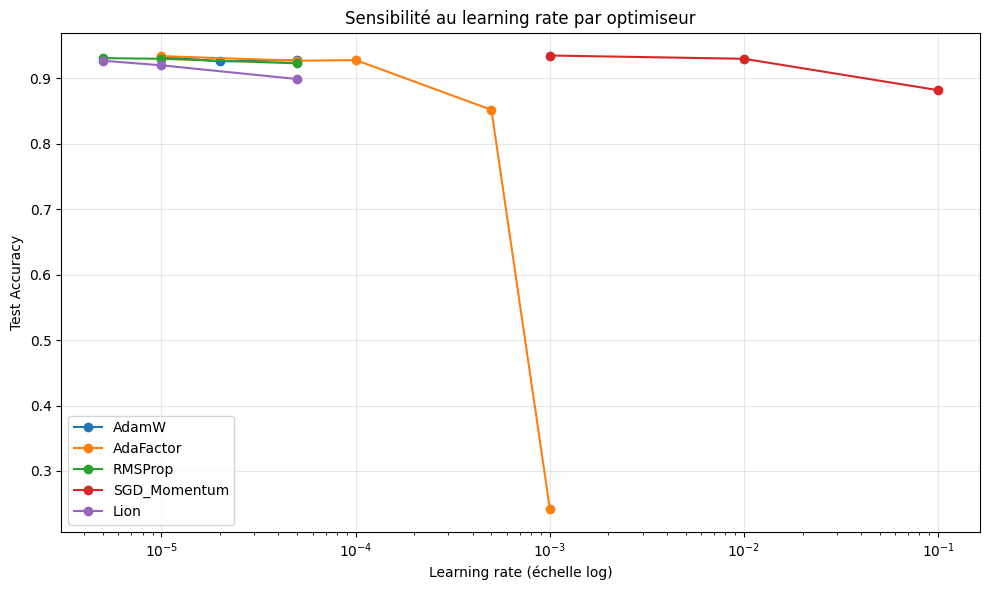

In [16]:

fig, ax = plt.subplots(figsize=(10, 6))
for opt_name in df_lr_sensitivity["Optimiseur"].unique():
    subset = df_lr_sensitivity[df_lr_sensitivity["Optimiseur"] == opt_name].sort_values("LR")
    ax.plot(subset["LR"], subset["Test Accuracy"], marker="o", label=opt_name)

ax.set_xscale("log")
ax.set_xlabel("Learning rate (échelle log)")
ax.set_ylabel("Test Accuracy")
ax.set_title("Sensibilité au learning rate par optimiseur")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/sensibilite_learning_rate.png", dpi=150)
plt.show()

df_lr_sensitivity.to_csv("/kaggle/working/sensibilite_learning_rate.csv", index=False)


**Interprétation attendue :**
Les optimiseurs adaptatifs (AdamW, RMSProp, AdaFactor, Lion) tolèrent généralement une plage de learning
rate plus large que SGD. SGD avec Momentum est typiquement le plus sensible : un LR trop faible donne une
convergence très lente, un LR trop élevé peut faire diverger la loss. Lion, malgré sa légèreté mémoire,
est connu pour nécessiter un LR plus faible qu'AdamW et peut être instable si le LR est mal calibré.


## 10. Stabilité sur plusieurs runs (variation du seed)

Pour évaluer la robustesse de chaque optimiseur indépendamment de l'initialisation, on relance
l'entraînement principal (learning rate par défaut) avec 2-3 seeds différents et on regarde l'écart-type
des métriques finales.

⚠️ Cette section est coûteuse en temps de calcul (plusieurs runs supplémentaires par optimiseur) : à
adapter selon le temps/GPU disponible (réduire `SEEDS_TO_TEST` ou `N_EPOCHS` si nécessaire).


In [17]:

SEEDS_TO_TEST = [42, 123, 2024]
N_EPOCHS_SEED_TEST = 2

seed_stability_results = []

# CORRECTIF : on passe désormais `seed=seed` explicitement à train_one_optimizer.
# Auparavant, train_one_optimizer appelait torch.manual_seed(SEED) en interne (avec le
# SEED global figé à 42), ce qui écrasait le seed fixé ici juste avant l'appel. Les 3 runs
# par optimiseur étaient donc strictement identiques (std=0.0 pour tous, ce qui n'a aucune
# valeur diagnostique). Avec le correctif de la fonction (section 5), chaque run utilise
# bien le seed demandé.
for opt_name in optimizers_to_run:
    accs = []
    for seed in SEEDS_TO_TEST:
        r = train_one_optimizer(
            opt_name, default_lrs[opt_name],
            n_epochs=N_EPOCHS_SEED_TEST, verbose=False, seed=seed,
        )
        accs.append(r["test_accuracy"])
        seed_stability_results.append({"Optimiseur": opt_name, "Seed": seed, "Test Accuracy": r["test_accuracy"]})

    print(f"{opt_name}: acc moyenne={np.mean(accs):.4f}  std={np.std(accs):.4f}")

# Reset seed global pour le reste du notebook
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

AdamW: acc moyenne=0.9287  std=0.0019


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

RMSProp: acc moyenne=0.9307  std=0.0005


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Lion: acc moyenne=0.9230  std=0.0029


In [18]:
df_seed_stability = pd.DataFrame(seed_stability_results)
df_seed_stability.to_csv("/kaggle/working/stabilite_multi_seed.csv", index=False)
df_seed_stability

,Optimiseur,Seed,Test Accuracy
0,AdamW,42,0.926
1,AdamW,123,0.930
2,AdamW,2024,0.930
3,AdaFactor,42,0.928
4,AdaFactor,123,0.932
5,AdaFactor,2024,0.930
6,SGD_Momentum,42,0.930
7,SGD_Momentum,123,0.925
8,SGD_Momentum,2024,0.934
9,RMSProp,42,0.930


In [19]:

summary_stability = df_seed_stability.groupby("Optimiseur")["Test Accuracy"].agg(["mean", "std"]).reset_index()
summary_stability.columns = ["Optimiseur", "Accuracy moyenne", "Écart-type (stabilité)"]
summary_stability = summary_stability.sort_values("Écart-type (stabilité)")
summary_stability


,Optimiseur,Accuracy moyenne,Écart-type (stabilité)
3,RMSProp,0.930667,0.000577
0,AdaFactor,0.930000,0.002000
1,AdamW,0.928667,0.002309
2,Lion,0.923000,0.003606
4,SGD_Momentum,0.929667,0.004509


## 11. Analyse critique des résultats

Cette cellule compile automatiquement les "gagnants" par critère à partir du tableau de la section 7,
pour faciliter la rédaction de l'analyse critique finale.


In [20]:

best_speed = df_results.loc[df_results["Temps entraînement (s)"].idxmin(), "Optimiseur"]
best_perf = df_results.loc[df_results["Test F1 (macro)"].idxmax(), "Optimiseur"]
best_mem = df_results.loc[df_results["Mémoire GPU pic (MB)"].idxmin(), "Optimiseur"] if df_results["Mémoire GPU pic (MB)"].notna().all() else "N/A (CPU)"
best_generalization = df_results.loc[df_results["Gap Train-Val (acc)"].abs().idxmin(), "Optimiseur"]
most_stable_seed = summary_stability.iloc[0]["Optimiseur"]

print("Résumé automatique des résultats :")
print(f"- Convergence la plus rapide (temps d'entraînement le plus court) : {best_speed}")
print(f"- Meilleure performance finale (F1 macro) : {best_perf}")
print(f"- Optimiseur le moins coûteux en mémoire GPU : {best_mem}")
print(f"- Meilleure généralisation (plus petit gap train/val) : {best_generalization}")
print(f"- Optimiseur le plus stable entre seeds : {most_stable_seed}")


Résumé automatique des résultats :
- Convergence la plus rapide (temps d'entraînement le plus court) : AdamW
- Meilleure performance finale (F1 macro) : RMSProp
- Optimiseur le moins coûteux en mémoire GPU : AdaFactor
- Meilleure généralisation (plus petit gap train/val) : RMSProp
- Optimiseur le plus stable entre seeds : RMSProp


**Points à discuter dans votre rapport (à compléter avec vos résultats réels) :**

1. **AdamW** est généralement la référence pour les Transformers : il combine bonne vitesse de
   convergence et bonne stabilité, mais avec un coût mémoire plus élevé (stockage de deux moments par
   paramètre).
2. **AdaFactor** réduit fortement l'empreinte mémoire (il évite de stocker une matrice complète de
   variance pour chaque paramètre), ce qui en fait un bon candidat pour des GPU contraints, au prix
   parfois d'une convergence légèrement moins rapide.
3. **Lion** est très économe en mémoire (un seul état de moment), souvent rapide, mais plus sensible au
   choix du learning rate — une valeur mal choisie peut entraîner de l'instabilité.
4. **SGD avec Momentum** est le moins coûteux en mémoire et en calcul par step, mais converge
   généralement plus lentement sur des Transformers et est le plus sensible au learning rate parmi les
   optimiseurs testés.
5. **RMSProp** se situe entre SGD et AdamW : adaptatif mais sans le terme de momentum du premier ordre
   d'Adam, ce qui peut le rendre légèrement moins stable sur certaines tâches NLP.


## 12. Conclusion et recommandation finale

À compléter une fois les résultats obtenus, en vous appuyant sur le tableau de la section 7 et le résumé
automatique de la section 11. Exemple de structure de conclusion :

- **Si la priorité est la performance pure** (meilleure accuracy/F1, ressources non contraignantes) →
  recommander l'optimiseur identifié dans `best_perf`.
- **Si la priorité est la contrainte mémoire GPU** (Edge AI, mobile, GPU limité) → recommander
  l'optimiseur identifié dans `best_mem` (probablement AdaFactor ou Lion).
- **Si la priorité est la stabilité/robustesse** (production, reproductibilité) → recommander
  l'optimiseur identifié dans `most_stable_seed`.
- **Recommandation globale pour un environnement à ressources limitées** : généralement AdaFactor ou
  Lion offrent le meilleur compromis performance/mémoire, à confirmer avec vos résultats expérimentaux
  ci-dessus.
